# Week 8 workshop: Numerical differentiation

Pair-program as usual for the code tasks. This week's workshop also involves some pen-and-paper work; you should discuss and work together with your team. You can try "pair problem-solving" -- one driver holds the pen and paper (or the whiteboard), and navigators help.

---

A general $N$-point finite difference approximation of the derivative $F' \left( x \right)$ of an appropriately smooth function $F \left( x \right)$ can be written as

$$
F' \left( x \right) \approx \frac{1}{\Delta x} \sum_{i = 1}^N \alpha_i F \left( x + \beta_i \Delta x \right),
\qquad \qquad \qquad (1)
$$

with step size $\Delta x > 0$, and $\alpha_i, \beta_i \in \mathbb{Q}$, with $\beta_i \neq \beta_j$ for $i\neq j$. For example, the centred difference approximation $D_C(x)$ seen in the course has $N = 2$, and

$$
\begin{cases}
\alpha_1 = \frac{1}{2}, &\alpha_2 = -\frac{1}{2}, \\
\beta_1 = 1, &\beta_2 = -1,
\end{cases}
\qquad
\text{giving} \quad
F'(x) \approx \frac{1}{2\Delta x} \left(F\left(x + \Delta x\right) - F\left(x - \Delta x\right)\right).
$$

---
### Task 1

Consider another finite difference approximation defined as in $(1)$, this time with $N=3$, and

$$
\begin{cases}
\alpha_1 = -\frac{4}{23}, &\alpha_2 = -\frac{9}{17}, &\alpha_3 = \frac{275}{391} \\
\beta_1 = -\frac{3}{2}, &\beta_2 = -\frac{1}{3}, &\beta_2 = \frac{4}{5}
\end{cases}.
$$

What is the order of accuracy of this finite difference approximation? Show this analytically, and perform numerical experiments to confirm your findings.

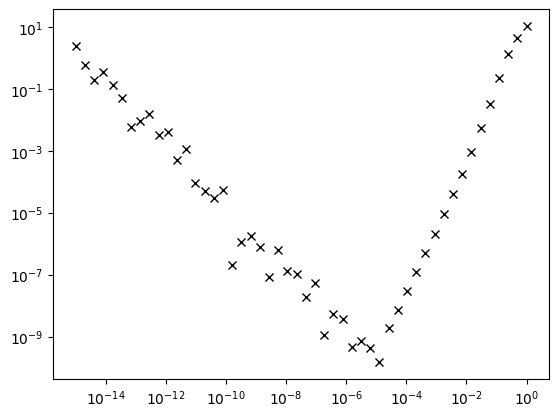

In [9]:
import numpy as np
import matplotlib.pyplot as plt
def F(x):
    return np.exp(x) * np.cos(5 * x)

def Fp(x):
    return F(x) - 5 * np.exp(x) * np.sin(5*x)

def D2(F, x, h, a, b):
    fx = 0
    for i in range(3):
        fx += a[i] * F(x + b[i]*h)
    return fx/h

x_0 = 2
h_vals = np.logspace(-15, 0, 50)
a = [-4/23, -9/17, 275/391]
b = [-3/2, -1/3, 4/5]
error_magnitudes = []
for h in h_vals:
    Fp_exact = Fp(x_0)
    Fp_approx = D2(F, x_0, h, a, b)
    Fp_error_magnitude = abs(Fp_exact - Fp_approx)
    error_magnitudes.append(Fp_error_magnitude)

fig, ax = plt.subplots()
ax.loglog(h_vals, error_magnitudes, "kx")
plt.show()


---
### Task 2

For any arbitrary choice of $\beta_i$ values, explain why the minimum number of points $N_{p}$ required to find an approximation $(1)$ which is at least $p$th order accurate, is $N_p = p+1$.

*Hint:* the Taylor expansion of $F \left( x + \beta_i \Delta x \right)$ around $F(x)$, for each term in the sum in $(1)$, is given by

$$
F \left( x + \beta_i \Delta x \right) =
\sum_{m=0}^\infty \frac{(\beta_i \Delta x)^m}{m!} \frac{d^m F}{dx^m} =
\sum_{m=0}^p \frac{(\beta_i \Delta x)^m}{m!} \frac{d^m F}{dx^m} + O(\Delta x^p).
$$

when we subsitute this taylor expansion into N-point expression and rearrange, we get that the Bi^1 coefficient must be 1 and all other powers 0 therefore generating p+1 equations, which need N = p+1 points minimum to be solveable. therefore need this many points.

---
### Task 3

Using your reasoning from Task 2, write a function `FD_coefficients()` which, given $N_p$ values $\beta_i$, returns $N_p$ coefficients $\alpha_i$ such that the approximation $(1)$ is at least $p$th order accurate.

Use your function to obtain the coefficients $\alpha_i$ from Task 1.

In [12]:
def FD_coefficients(bi):
    b = np.zeros(len(bi))
    b[1] = 1
    bmat = np.zeros(shape = (len(bi), len(bi)))
    for i in range(len(bi)):
        for j in range(len(bi)):
            bmat[i][j] = bi[j]**i
    ai = np.linalg.solve(bmat, b)
    return ai

b = [-3/2, -1/3, 4/5]
print(FD_coefficients(b))

[-0.17391304 -0.52941176  0.70332481]


---
### Bonus task

Experiment with choosing other values for $N_p$ and $\beta_i$, and using your function `FD_coefficients()` to calculate the coefficients $\alpha_i$: reproduce your analysis from Task 1 to confirm that no matter the choice of (distinct) $\beta_i$ values, the order of accuracy is at least $p = N_p - 1$.

Can you find any example choices of $\beta_i$ which lead to an order of accuracy greater than $N_p - 1$?